# SWDP TinyML Dataset Feature and Generalization Analysis

This notebook performs a deep-dive analysis on the context-classification dataset (`tinyml_features.csv`).

The objective is to evaluate class balance, analyze session-level recording distribution, and run a feature importance model (Random Forest) to understand which sensors and features are driving the model's predictions. This helps diagnose generalization bottlenecks and prioritize new data collection.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})
print("Imports and plotting settings configured successfully.")

Imports and plotting settings configured successfully.


## 1. Load Dataset and High-Level Profiling

We load `tinyml_features.csv` and profile the dataset: evaluating class distributions and listing the unique recording session counts per class.

In [12]:
df = pd.read_csv("output/tinyml_features.csv")
print(f"Dataset shape: {df.shape}")

# Display basic counts
print("\n--- Target Class Balance ---")
counts = df["label"].value_counts()
pcts = df["label"].value_counts(normalize=True) * 100
for cls in counts.index:
    print(f"{cls:<15}: {counts[cls]:>4} windows ({pcts[cls]:.2f}%)")

print("\n--- Session-Level (Recording ID) Breakdown ---")
sessions = df.groupby("label")["recording_id"].nunique()
for cls in sessions.index:
    print(f"{cls:<15}: {sessions[cls]} unique recording session(s)")

Dataset shape: (1885, 46)

--- Target Class Balance ---
INDOOR_NORMAL  :  526 windows (27.90%)
OUTDOOR        :  521 windows (27.64%)
INDOOR_QUIET   :  460 windows (24.40%)
COVERED_DARK   :  212 windows (11.25%)
UNDERGROUND    :  166 windows (8.81%)

--- Session-Level (Recording ID) Breakdown ---
COVERED_DARK   : 2 unique recording session(s)
INDOOR_NORMAL  : 4 unique recording session(s)
INDOOR_QUIET   : 4 unique recording session(s)
OUTDOOR        : 4 unique recording session(s)
UNDERGROUND    : 2 unique recording session(s)


## 2. Feature Importance Analysis

We fit a Random Forest model on the dataset to estimate the Gini importance of the features. This highlights which specific features are driving predictions.

/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/ipykernel_7899/374719749.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="viridis")


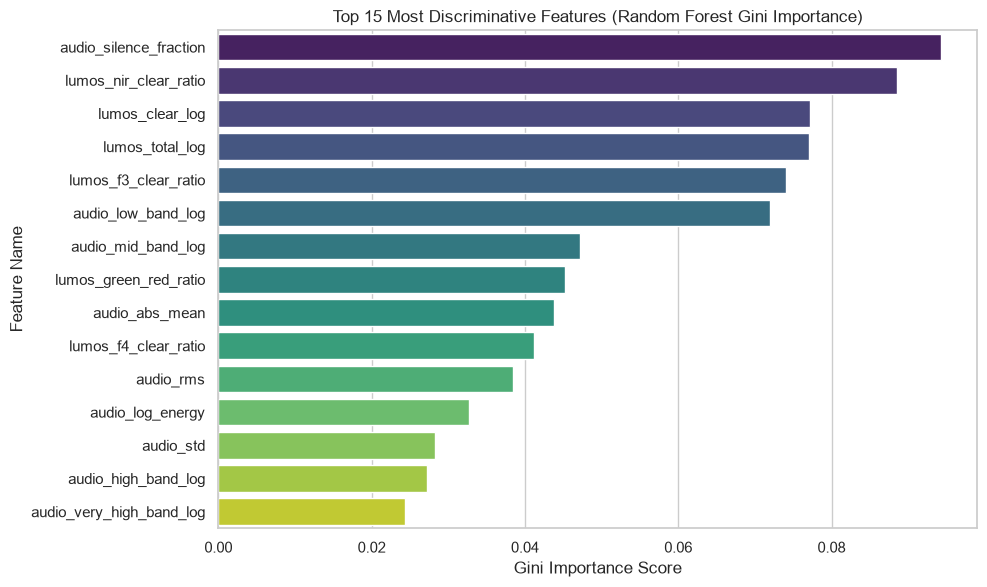


Top 10 features and their importance scores:
 1. audio_silence_fraction        : 0.0943
 2. lumos_nir_clear_ratio         : 0.0885
 3. lumos_clear_log               : 0.0773
 4. lumos_total_log               : 0.0770
 5. lumos_f3_clear_ratio          : 0.0741
 6. audio_low_band_log            : 0.0719
 7. audio_mid_band_log            : 0.0472
 8. lumos_green_red_ratio         : 0.0452
 9. audio_abs_mean                : 0.0438
10. lumos_f4_clear_ratio          : 0.0412


In [13]:
# Separate features and target
excluded = {"recording_id", "source_file", "label", "window_start_packet", "window_end_packet", "window_start_s", "window_end_s"}
feature_cols = [c for c in df.columns if c not in excluded]

X = df[feature_cols]
y = df["label"]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X, y)

# Get importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="viridis")
plt.title("Top 15 Most Discriminative Features (Random Forest Gini Importance)")
plt.xlabel("Gini Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

print("\nTop 10 features and their importance scores:")
for idx, (feat, imp) in enumerate(importances.head(10).items()):
    print(f"{idx+1:>2}. {feat:<30}: {imp:.4f}")

## 3. Top Feature Distribution Visualizations

We plot class-wise distributions of the top 4 most important features to see if classes have distinct thresholds or if they overlap.

/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/ipykernel_7899/3018941885.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feat, ax=axes[idx], palette="Set2")
/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/ipykernel_7899/3018941885.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feat, ax=axes[idx], palette="Set2")
/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/ipykernel_7899/3018941885.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=feat, ax=axes[idx], palette=

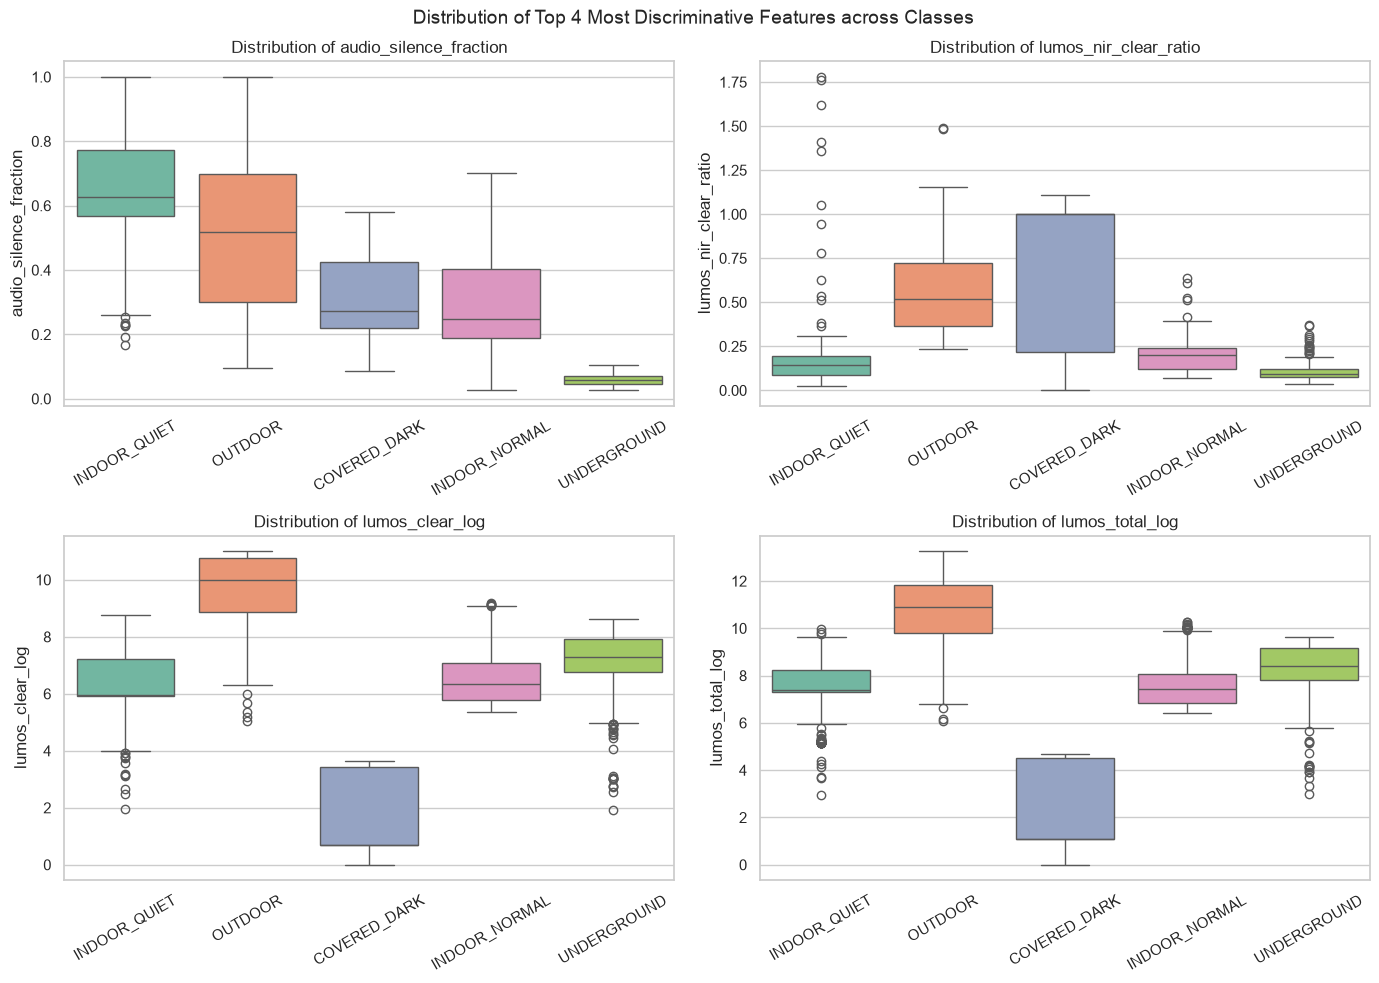

In [14]:
top_features = list(importances.head(4).index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    sns.boxplot(data=df, x="label", y=feat, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"Distribution of {feat}")
    axes[idx].set_xlabel("")
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle("Distribution of Top 4 Most Discriminative Features across Classes")
plt.tight_layout()
plt.show()

## 4. Cumulative Sensor Family Importance

We group the importances by the sensor domain to identify which sensor family (Spectrometer, Audio, or Flicker) contributes the most to classification accuracy.

In [15]:
# Group features by sensor family
sensor_map = {
    "lumos_": "Spectral (AS7341)",
    "audio_": "Microphone Audio",
    "flicker_": "Flicker Tracker"
}

family_importance = {}
for feat, imp in importances.items():
    found = False
    for prefix, family in sensor_map.items():
        if feat.startswith(prefix):
            family_importance[family] = family_importance.get(family, 0.0) + imp
            found = True
            break
    if not found:
        family_importance["Other"] = family_importance.get("Other", 0.0) + imp

print("--- Cumulative Sensor Family Importance ---")
for family, imp in sorted(family_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{family:<25}: {imp:.4f} ({imp*100:.1f}%)")

--- Cumulative Sensor Family Importance ---
Microphone Audio         : 0.4984 (49.8%)
Spectral (AS7341)        : 0.4962 (49.6%)
Flicker Tracker          : 0.0055 (0.5%)
